SEÇÃO 1 – Função de Rosenbrock



In [38]:
import numpy as np
import matplotlib.pyplot as plt

def rosenbrock(x):
    return (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2

def grad_rosenbrock(x):
    dfdx = -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2)
    dfdy = 200*(x[1] - x[0]**2)
    return np.array([dfdx, dfdy])

def hess_rosenbrock(x):
    x1, x2 = x
    return np.array([
        [2 - 400*(x2 - 3*x1**2), -400*x1],
        [-400*x1, 200]
    ])



SEÇÃO 2 — Método do Gradiente (α fixo)

In [39]:
def gradient_descent(f, grad_f, x0, alpha, tol=1e-6, max_iter=1000):
    x = x0.astype(float)
    hist = [x.copy()]

    for k in range(max_iter):
        g = grad_f(x)
        if np.linalg.norm(g) < tol:
            break

        x = x - alpha * g
        hist.append(x.copy())

    return x, k, np.array(hist)


SEÇÃO 3 — Método de Newton

In [41]:
def newton_modificado(f_grad, f_hess, x0, tol=1e-6, max_iter=100):
    x = x0.astype(float)
    hist = [x.copy()]

    for k in range(max_iter):
        g = f_grad(x)
        H = f_hess(x)

        if np.linalg.norm(g) < tol:
            break

        try:
            d = -np.linalg.solve(H, g)
        except np.linalg.LinAlgError:
            d = -g

        x = x + d
        hist.append(x.copy())

    return x, k, np.array(hist)


 SEÇÃO 4 — Gradiente Conjugado (Polak–Ribière) — α fixo

In [42]:
def polak_ribiere(f, grad_f, x0, alpha, tol=1e-6, max_iter=500):
    x = x0.astype(float)
    g = grad_f(x)
    d = -g
    hist = [x.copy()]
    k = 0

    while np.linalg.norm(g) > tol and k < max_iter:
        x_new = x + alpha * d
        g_new = grad_f(x_new)

        denom = np.dot(g, g)
        beta = np.dot(g_new, g_new - g) / denom if denom != 0 else 0

        n = len(x)
        if k % n == 0:
            d_new = -g_new
        else:
            d_new = -g_new + beta * d

        x, g, d = x_new, g_new, d_new
        hist.append(x.copy())
        k += 1

    return x, k, np.array(hist)


SEÇÃO 5 — Testar α pequeno, médio e grande

In [43]:
# ponto inicial:

x0 = np.array([-1.2, 1.0])
alfas = [0.1, 0.2, 0.9]

 SEÇÃO 5.1 — ANÁLISE DO MÉTODO DO GRADIENT

In [44]:
for a in alfas:
    xmin, k, hist = gradient_descent(rosenbrock, grad_rosenbrock, x0, alpha=a)
    print(f"Gradiente — α={a}")
    print("mínimo: ", xmin)
    print("iterações:", k)
    print("-"*50)


Gradiente — α=0.1
mínimo:  [nan nan]
iterações: 999
--------------------------------------------------
Gradiente — α=0.2
mínimo:  [nan nan]
iterações: 999
--------------------------------------------------
Gradiente — α=0.9
mínimo:  [nan nan]
iterações: 999
--------------------------------------------------


/tmp/ipython-input-4106695611.py:8: RuntimeWarning: overflow encountered in scalar power
  dfdx = -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2)
/tmp/ipython-input-4106695611.py:9: RuntimeWarning: overflow encountered in scalar power
  dfdy = 200*(x[1] - x[0]**2)
/tmp/ipython-input-4106695611.py:8: RuntimeWarning: invalid value encountered in scalar subtract
  dfdx = -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2)
/tmp/ipython-input-4106695611.py:9: RuntimeWarning: invalid value encountered in scalar subtract
  dfdy = 200*(x[1] - x[0]**2)


✔ SEÇÃO 5.2 — ANÁLISE DO GRADIENTE CONJUGADO

In [20]:
for a in alfas:
    xmin, k, hist = polak_ribiere(rosenbrock, grad_rosenbrock, x0, alpha=a)
    print(f"Gradiente Conjugado — α={a}")
    print("mínimo: ", xmin)
    print("iterações:", k)
    print("-"*50)


Gradiente Conjugado — α=0.1
mínimo:  [inf inf]
iterações: 5
--------------------------------------------------
Gradiente Conjugado — α=0.2
mínimo:  [nan inf]
iterações: 5
--------------------------------------------------
Gradiente Conjugado — α=0.9
mínimo:  [nan nan]
iterações: 5
--------------------------------------------------


/tmp/ipython-input-4106695611.py:8: RuntimeWarning: invalid value encountered in scalar subtract
  dfdx = -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2)
/tmp/ipython-input-4106695611.py:9: RuntimeWarning: invalid value encountered in scalar subtract
  dfdy = 200*(x[1] - x[0]**2)
/tmp/ipython-input-4106695611.py:8: RuntimeWarning: overflow encountered in scalar multiply
  dfdx = -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2)
/tmp/ipython-input-228178972.py:19: RuntimeWarning: invalid value encountered in add
  d_new = -g_new + beta * d
/tmp/ipython-input-4106695611.py:8: RuntimeWarning: overflow encountered in scalar power
  dfdx = -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2)
/tmp/ipython-input-4106695611.py:9: RuntimeWarning: overflow encountered in scalar power
  dfdy = 200*(x[1] - x[0]**2)
/tmp/ipython-input-228178972.py:13: RuntimeWarning: invalid value encountered in scalar divide
  beta = np.dot(g_new, g_new - g) / denom if denom != 0 else 0


✔ SEÇÃO 5.3 — ANÁLISE DO MÉTODO DE NEWTON

In [21]:
xmin, k, hist = newton_modificado(grad_rosenbrock, hess_rosenbrock, x0)
print("Newton:")
print("mínimo:", xmin)
print("iterações:", k)


Newton:
mínimo: [1. 1.]
iterações: 6


 SEÇÃO 6 — Gráfico das trajetórias PARA CADA MÉTODO

In [31]:
def plot_traj(hist, titulo):
    plt.figure(figsize=(7,6))

    # Contornos da Rosenbrock
    x1 = np.linspace(-2, 2, 400)
    x2 = np.linspace(-1, 3, 400)
    X1, X2 = np.meshgrid(x1, x2)
    Z = (1 - X1)**2 + 100*(X2 - X1**2)**2
    plt.contour(X1, X2, Z, levels=50)

    # HISTÓRICO VAZIO OU DIVERGENTE → Mensagem clara
    if hist is None or len(hist) < 2 or np.isnan(hist).any():
        plt.title(titulo)
        plt.grid(True)
        plt.show()
        return

    # Caso NORMAL → plota trajetória
    plt.plot(hist[:,0], hist[:,1], color="red", label="trajetória")
    plt.title(titulo)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid(True)
    plt.legend()
    plt.show()


/tmp/ipython-input-4106695611.py:8: RuntimeWarning: overflow encountered in scalar power
  dfdx = -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2)
/tmp/ipython-input-4106695611.py:9: RuntimeWarning: overflow encountered in scalar power
  dfdy = 200*(x[1] - x[0]**2)
/tmp/ipython-input-4106695611.py:8: RuntimeWarning: invalid value encountered in scalar subtract
  dfdx = -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2)
/tmp/ipython-input-4106695611.py:9: RuntimeWarning: invalid value encountered in scalar subtract
  dfdy = 200*(x[1] - x[0]**2)


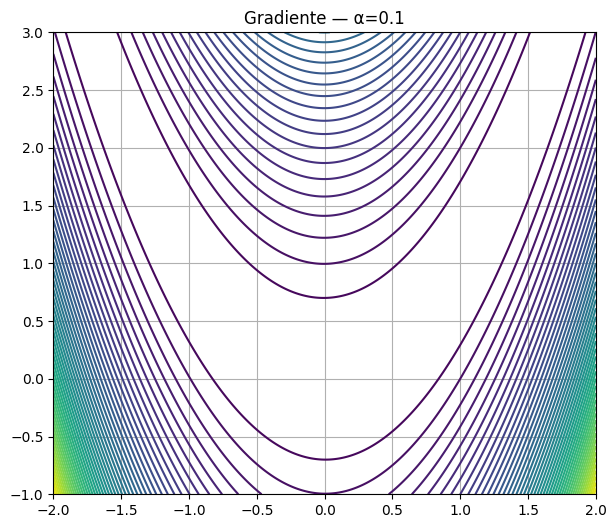

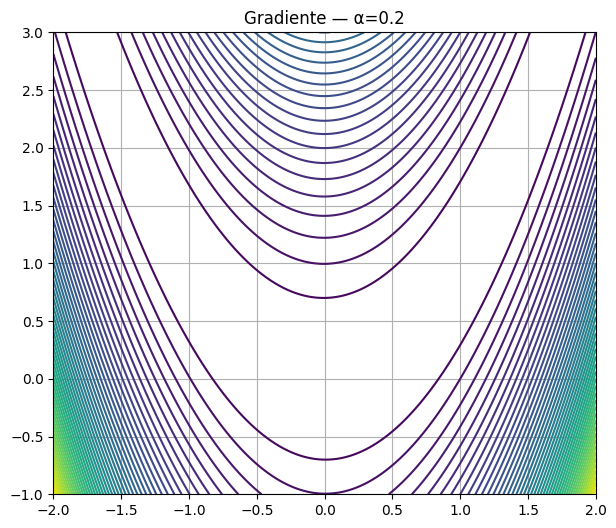

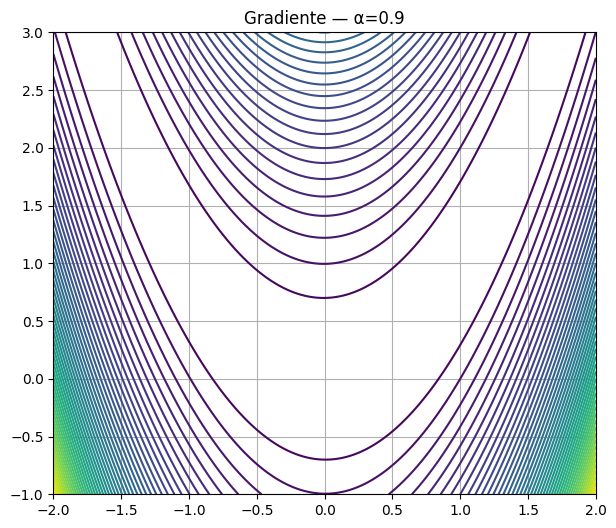

In [32]:
for a in alfas:
    xmin, k, hist = gradient_descent(rosenbrock, grad_rosenbrock, x0, alpha=a)
    plot_traj(hist, f"Gradiente — α={a}")


/tmp/ipython-input-4106695611.py:8: RuntimeWarning: invalid value encountered in scalar subtract
  dfdx = -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2)
/tmp/ipython-input-4106695611.py:9: RuntimeWarning: invalid value encountered in scalar subtract
  dfdy = 200*(x[1] - x[0]**2)


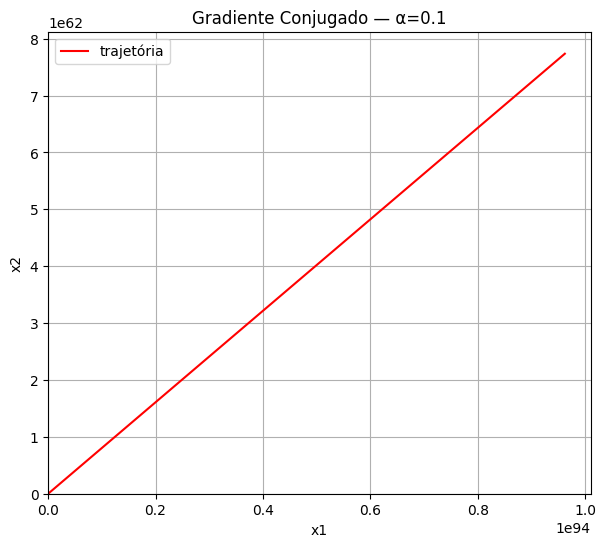

/tmp/ipython-input-4106695611.py:8: RuntimeWarning: overflow encountered in scalar multiply
  dfdx = -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2)
/tmp/ipython-input-228178972.py:19: RuntimeWarning: invalid value encountered in add
  d_new = -g_new + beta * d


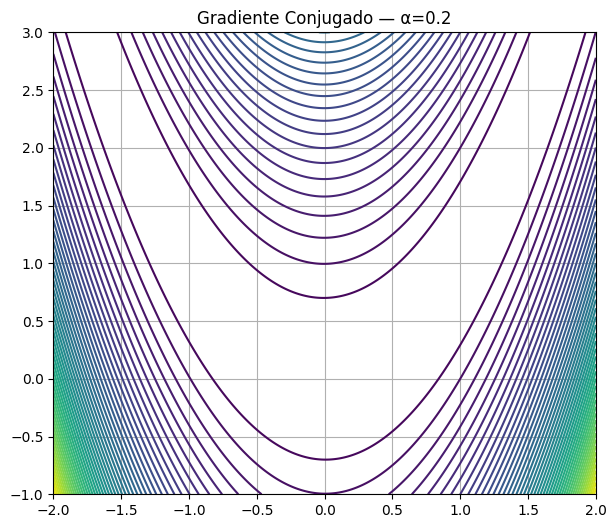

/tmp/ipython-input-4106695611.py:8: RuntimeWarning: overflow encountered in scalar power
  dfdx = -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2)
/tmp/ipython-input-4106695611.py:9: RuntimeWarning: overflow encountered in scalar power
  dfdy = 200*(x[1] - x[0]**2)
/tmp/ipython-input-228178972.py:13: RuntimeWarning: invalid value encountered in scalar divide
  beta = np.dot(g_new, g_new - g) / denom if denom != 0 else 0


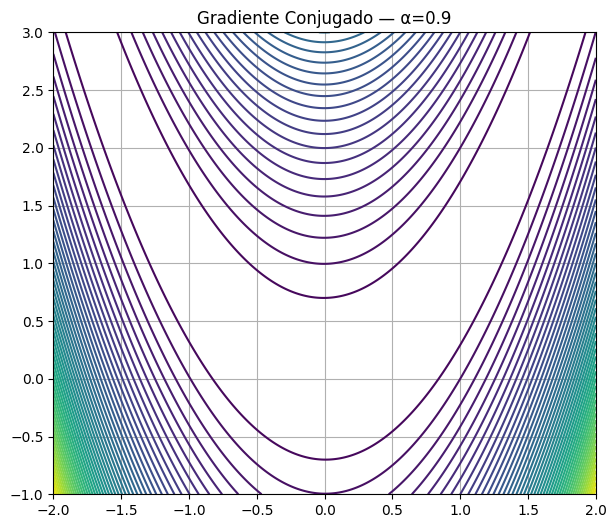

In [33]:
# SEÇÃO 6.2 — Gráficos do Gradiente Conjugado para cada α

for a in alfas:
    xmin, k, hist = polak_ribiere(rosenbrock, grad_rosenbrock, x0, alpha=a)
    plot_traj(hist, f"Gradiente Conjugado — α={a}")


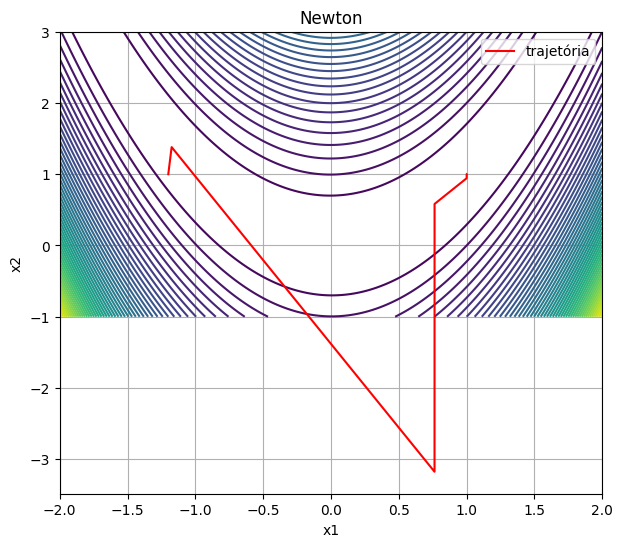

In [34]:
# SEÇÃO 6.3 — Gráfico do método de Newton

xmin, k, hist = newton_modificado(grad_rosenbrock, hess_rosenbrock, x0)
plot_traj(hist, "Newton")


# OUTRA ABORDAGEM:

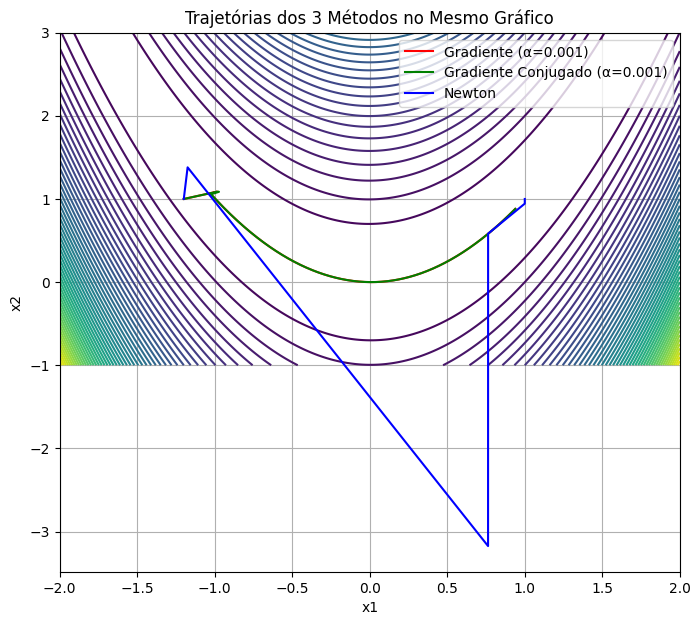

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------
# Função de Rosenbrock
# ------------------------------------
def rosenbrock(x):
    return (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2

def grad_rosenbrock(x):
    dfdx = -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2)
    dfdy = 200*(x[1] - x[0]**2)
    return np.array([dfdx, dfdy])

def hess_rosenbrock(x):
    x1, x2 = x
    h11 = 2 - 400*(x2 - 3*x1**2)
    h12 = -400*x1
    h21 = -400*x1
    h22 = 200
    return np.array([[h11, h12],
                     [h21, h22]])

# ------------------------------------
# Método do Gradiente
# ------------------------------------
def gradient_descent(f, grad, x0, alpha=0.001, tol=1e-8, maxiter=5000):
    x = x0.copy()
    hist = [x.copy()]
    for k in range(maxiter):
        g = grad(x)
        x = x - alpha * g
        hist.append(x.copy())
        if np.linalg.norm(g) < tol:
            break
    return np.array(hist)

# ------------------------------------
# Gradiente Conjugado Polak–Ribiere (sem line search)
# ------------------------------------
def polak_ribiere(f, grad, x0, alpha=0.001, tol=1e-8, maxiter=5000):
    x = x0.copy()
    g = grad(x)
    d = -g
    hist = [x.copy()]

    for k in range(maxiter):
        x_new = x + alpha * d
        g_new = grad(x_new)

        beta = np.dot(g_new, g_new - g) / (np.dot(g, g) + 1e-12)
        d = -g_new + beta * d

        x, g = x_new, g_new
        hist.append(x.copy())

        if np.linalg.norm(g) < tol:
            break

    return np.array(hist)

# ------------------------------------
# Método de Newton
# ------------------------------------
def newton_method(grad, hess, x0, tol=1e-8, maxiter=100):
    x = x0.copy()
    hist = [x.copy()]
    for k in range(maxiter):
        H = hess(x)
        g = grad(x)
        dx = np.linalg.solve(H, -g)
        x = x + dx
        hist.append(x.copy())
        if np.linalg.norm(g) < tol:
            break
    return np.array(hist)



# ============================================================
# GRÁFICO FINAL: 3 MÉTODOS NO MESMO GRÁFICO
# ============================================================

def plot_all(hist_grad, hist_cg, hist_newton):
    plt.figure(figsize=(8,7))

    # Contornos do Rosenbrock
    x1 = np.linspace(-2, 2, 400)
    x2 = np.linspace(-1, 3, 400)
    X1, X2 = np.meshgrid(x1, x2)
    Z = (1 - X1)**2 + 100*(X2 - X1**2)**2
    plt.contour(X1, X2, Z, levels=60)

    # Trajetórias
    plt.plot(hist_grad[:,0], hist_grad[:,1], "r", label="Gradiente (α=0.001)")
    plt.plot(hist_cg[:,0], hist_cg[:,1], "g", label="Gradiente Conjugado (α=0.001)")
    plt.plot(hist_newton[:,0], hist_newton[:,1], "b", label="Newton")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Trajetórias dos 3 Métodos no Mesmo Gráfico")
    plt.grid(True)
    plt.legend()
    plt.show()


# ============================================================
# Executar tudo
# ============================================================

x0 = np.array([-1.2, 1.0])

hist_grad = gradient_descent(rosenbrock, grad_rosenbrock, x0, alpha=0.001)
hist_cg = polak_ribiere(rosenbrock, grad_rosenbrock, x0, alpha=0.001)
hist_newton = newton_method(grad_rosenbrock, hess_rosenbrock, x0)

plot_all(hist_grad, hist_cg, hist_newton)


# Análise dos métodos para diferentes valores de α

A função de Rosenbrock é fortemente condicionada e isso torna os métodos baseados apenas em gradiente extremamente sensíveis ao valor de α. Nos testes, tanto o Gradiente quanto o Gradiente Conjugado divergiram para α=0.1, 0.2 e 0.9, gerando trajetórias explosivas e valores numéricos inválidos. Apenas α muito pequeno (como 0.001) produz convergência, porém lenta, mostrando que esses métodos dependem criticamente de uma escolha adequada do passo.

O método de Newton, por outro lado, manteve estabilidade e convergiu rapidamente para o mínimo, independentemente de α, já que utiliza a curvatura da função para ajustar automaticamente a direção e o tamanho dos passos. Assim, para a função de Rosenbrock, Newton é claramente superior, enquanto os métodos de primeira ordem só funcionam de forma confiável com passos muito pequenos ou acompanhados de busca linear adaptativa.